In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import yaml

In [2]:
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [3]:
# import the datasets
final_demo = pd.read_csv(config["input_data"]["file1"])
df_final_experiment_clients =pd.read_csv(config["input_data"]["file2"])
df_final_web_data_pt_1 = pd.read_csv(config["input_data"]["file3"])
df_final_web_data_pt_2 = pd.read_csv(config["input_data"]["file4"])

In [4]:
# check if there is an issue of column type
final_demo.dtypes, df_final_experiment_clients.dtypes, df_final_web_data_pt_1.dtypes

(client_id             int64
 clnt_tenure_yr      float64
 clnt_tenure_mnth    float64
 clnt_age            float64
 gendr                   str
 num_accts           float64
 bal                 float64
 calls_6_mnth        float64
 logons_6_mnth       float64
 dtype: object,
 client_id    int64
 Variation      str
 dtype: object,
 client_id       int64
 visitor_id        str
 visit_id          str
 process_step      str
 date_time         str
 dtype: object)

The dtype shows that the client_id is always an integer so theire is no issue for joining df

In [5]:
# remove rows from df_exeprimental_clients where variation is NA
df_final_experiment_clients = df_final_experiment_clients.dropna(subset=["Variation"])
df_final_experiment_clients.shape 

(50500, 2)

The decrease of number of rows matches the limitation to clients that participated

### Merge process

In [6]:
# combine the web data
concat_webdata = pd.concat([df_final_web_data_pt_1, df_final_web_data_pt_1], axis=0, join="outer")
concat_webdata.shape

(686282, 5)

In [7]:
# merge the demo
merged_demo = concat_webdata.merge(final_demo, on="client_id",how="left")
merged_demo.shape

(686282, 13)

The constant number of rows show the left join was made properly

In [8]:
# merge the experimental_clients
merged_experiment = merged_demo.merge(df_final_experiment_clients, on="client_id",how="left")
merged_experiment.shape

(686282, 14)

The constant number of rows show the left join was made properly

In [9]:
# separate process from final df
df = merged_experiment.copy()

### Fixing steps

In [10]:
# fix : clean the duplicates values
df.drop_duplicates(inplace=True)

In [11]:
# fix: keep clients involved in the AB Testing
df = df.dropna(subset=["Variation"])

In [12]:
# fix: convert date str into a datetime
df['date_time'] = pd.to_datetime(df['date_time'])
df.shape

(239985, 14)

Some client_ids were not matching. For example client_id = 6373617 was in df_final_web_data_pt_2 but not in expepriment either demo. This suggests a discrepancies between datasets (client_id in web data but not in demo for example)

Merge data process:
First the 2 web-data files have been concatenated in order to get the biggest dataset of the process, with the prior variables to be investigated.
Second, this dataset merged additional columns from final_demo which is the clients demographics.
Third, the final exprimental client dataset was added in order to see if the client was involved in a test or control group.
Then we assume to keep only data from our 2 samples.

### Check timeframe and potential cuts

In [13]:
# check if the process wac cut the first and last days of the experience
first_d = df['date_time'].min()
last_d = df['date_time'].max()
first_d,last_d

(Timestamp('2017-03-15 00:19:28'), Timestamp('2017-04-30 23:58:00'))

The last date of web data is 30th of April. Therefore, it is within the exprimental timeframe (June)

In [14]:
first_day_sample = df[df['date_time'].dt.date == pd.to_datetime('2017-03-15').date()].sort_values(by=['date_time'], ascending=True).head(5)[['process_step', 'date_time']]
first_day_sample

,process_step,date_time
35293,start,2017-03-15 00:19:28
35292,step_1,2017-03-15 00:20:50
35291,step_2,2017-03-15 00:22:52
35290,step_3,2017-03-15 00:23:47
35289,confirm,2017-03-15 00:26:24


The first user completed the entire process therefore we consider there was no cut of the process due to the timeframe

In [15]:
# Export main merge only
df_main = df.to_csv(config["output_data"]["file5"])

### Keep first start datetime and last confirm datetime (Rachel)

# First start
first_start = (
    df[df['process_step'] == 'start']
    .groupby('visit_id', as_index=False)['date_time']
    .min()
    .rename(columns={'date_time': 'first_start_time'})
)

# Last confirm
last_confirm = (
    df[df['process_step'] == 'confirm']
    .groupby('visit_id', as_index=False)['date_time']
    .max()
    .rename(columns={'date_time': 'last_confirm_time'})
)

# Keep only visits that have both a start and a confirm
visit_limits = first_start.merge(last_confirm, on='visit_id', how='inner')

# Attach those limits back to the original data
df = df.merge(visit_limits, on='visit_id', how='inner')

# Keep only rows between first start and last confirm
df = df[
    (df['date_time'] >= df['first_start_time']) &
    (df['date_time'] <= df['last_confirm_time'])
].copy()

# Sort neatly
df = df.sort_values(['visit_id', 'date_time'])
df = df.reset_index(drop=True)

df.head(20)

# Export main merge only
df_time_window = df.to_csv(config["output_data"]["file7"])

In [16]:
df_numerical = df[['clnt_tenure_mnth','clnt_age','num_accts','bal','calls_6_mnth','logons_6_mnth']]
df_numerical.head(2)

,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
0,64.0,79.0,2.0,189023.86,1.0,4.0
1,64.0,79.0,2.0,189023.86,1.0,4.0


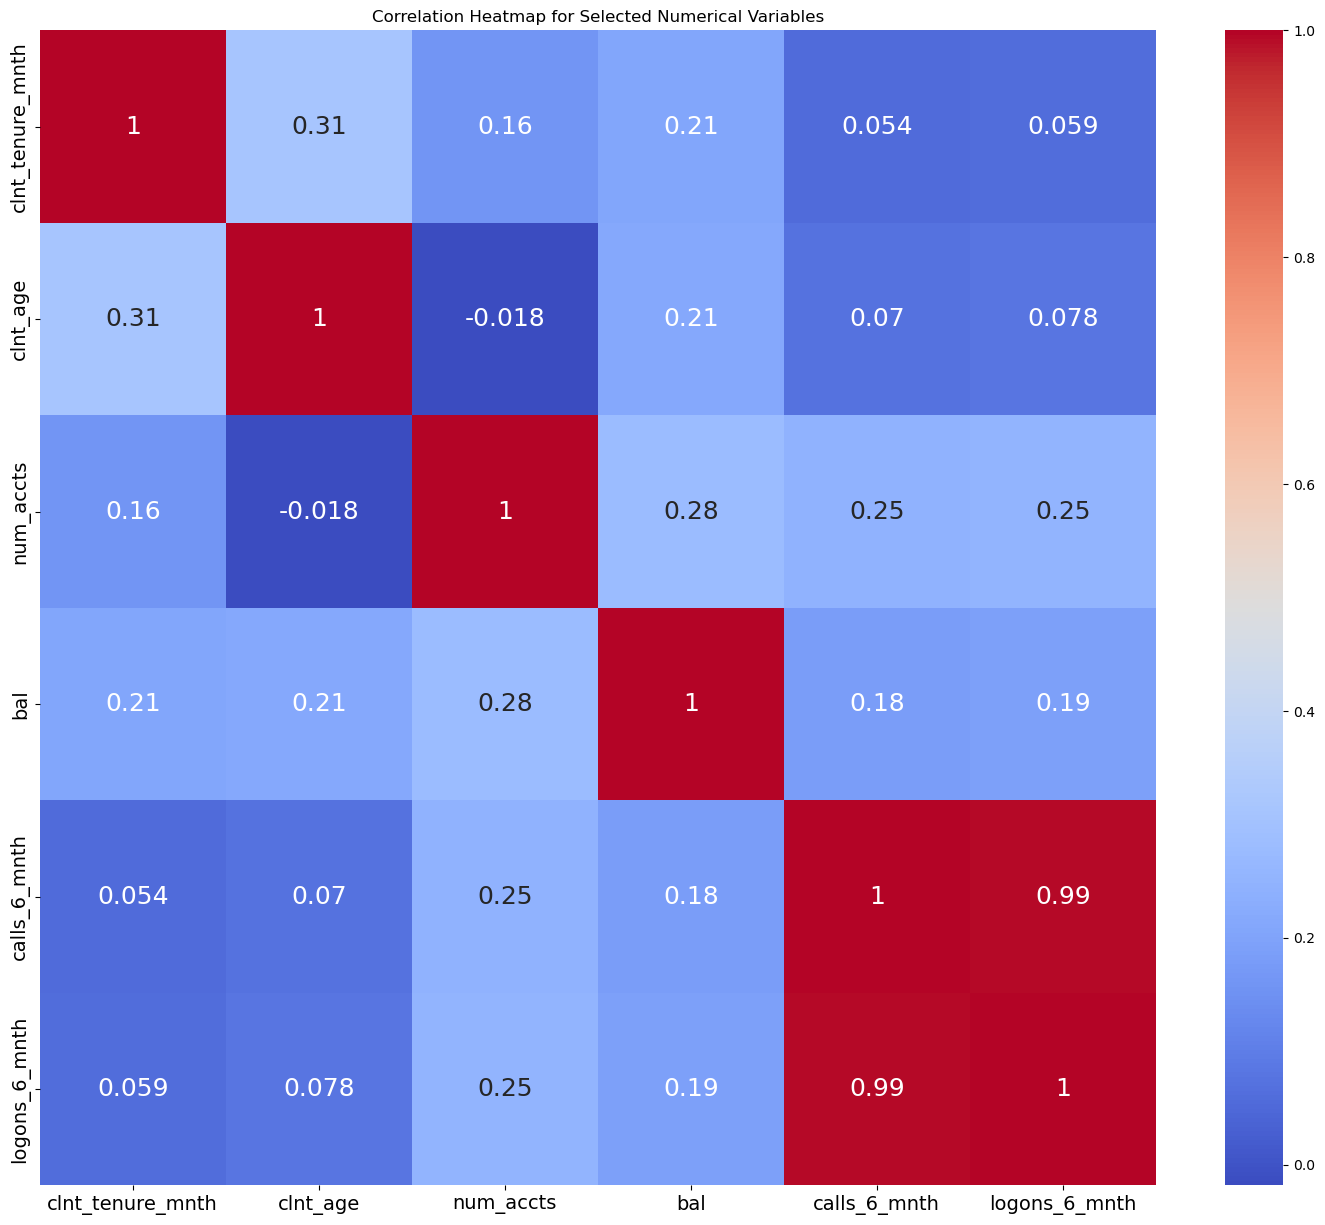

In [98]:
correlation_matrix = df_numerical.corr()

# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(18,15))

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True,annot_kws={"size": 18}, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.savefig('vanguard_corrheatmap.png')
plt.show()

result 1: no significative correlation between numerical variables

In [17]:
#data cleaning for gender
df['gendr'] = df['gendr'].replace('X', 'U')

In [20]:
# create the final dataset for kp1 completed visits and steps for analysis and correlation
df_grouped = df.groupby(['visit_id']).agg(
    duration=('date_time', lambda x: x.max() - x.min()),
    clnt_tenure_mnth=('clnt_tenure_mnth', 'min'),
    clnt_age=('clnt_age', 'min'),
    gendr=('gendr', 'min'),
    bal=('bal', 'min'),
    Variation=('Variation', 'min')
).reset_index()
df_grouped['duration'] = df_grouped['duration'].dt.total_seconds() / 60
df_visits = pd.read_csv(r"C:\Users\Utilisateur\Desktop\IRONHACK_DA\COURSES\week-5\vanguard-ab-test\data\clean\kp1_visits.csv")
visits = df_grouped.merge(df_visits, on="visit_id",how="left")

In [21]:
# Calculating the Spearman correlation coefficients between 'duration' and all other numerical variables
visits_numerical = visits[['clnt_tenure_mnth','clnt_age','bal','duration']].reset_index()

spearman_correlations = visits_numerical.corrwith(visits_numerical['duration'], method='spearman')

# Sorting the correlations for better visualization
spearman_correlations_sorted = spearman_correlations.sort_values(ascending=False)

# Displaying the correlations
spearman_correlations_sorted

duration            1.000000
clnt_age            0.077433
clnt_tenure_mnth    0.007911
bal                 0.002895
index              -0.002997
dtype: float64

No correlation betwenn duration and other numerical variables

In [ ]:
# Calculating the Spearman correlation coefficients between 'duration' and all other numerical variables
visits_numerical = visits[['clnt_tenure_mnth','clnt_age','bal','duration']].reset_index()

spearman_correlations = visits_numerical.corrwith(visits_numerical['duration'], method='spearman')

# Sorting the correlations for better visualization
spearman_correlations_sorted = spearman_correlations.sort_values(ascending=False)

# Displaying the correlations
spearman_correlations_sorted

graphs suggest similar patterns among groups, therefore each group seems to represent accordingly the clients 

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_48400\3168216480.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_48400\3168216480.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_48400\3168216480.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


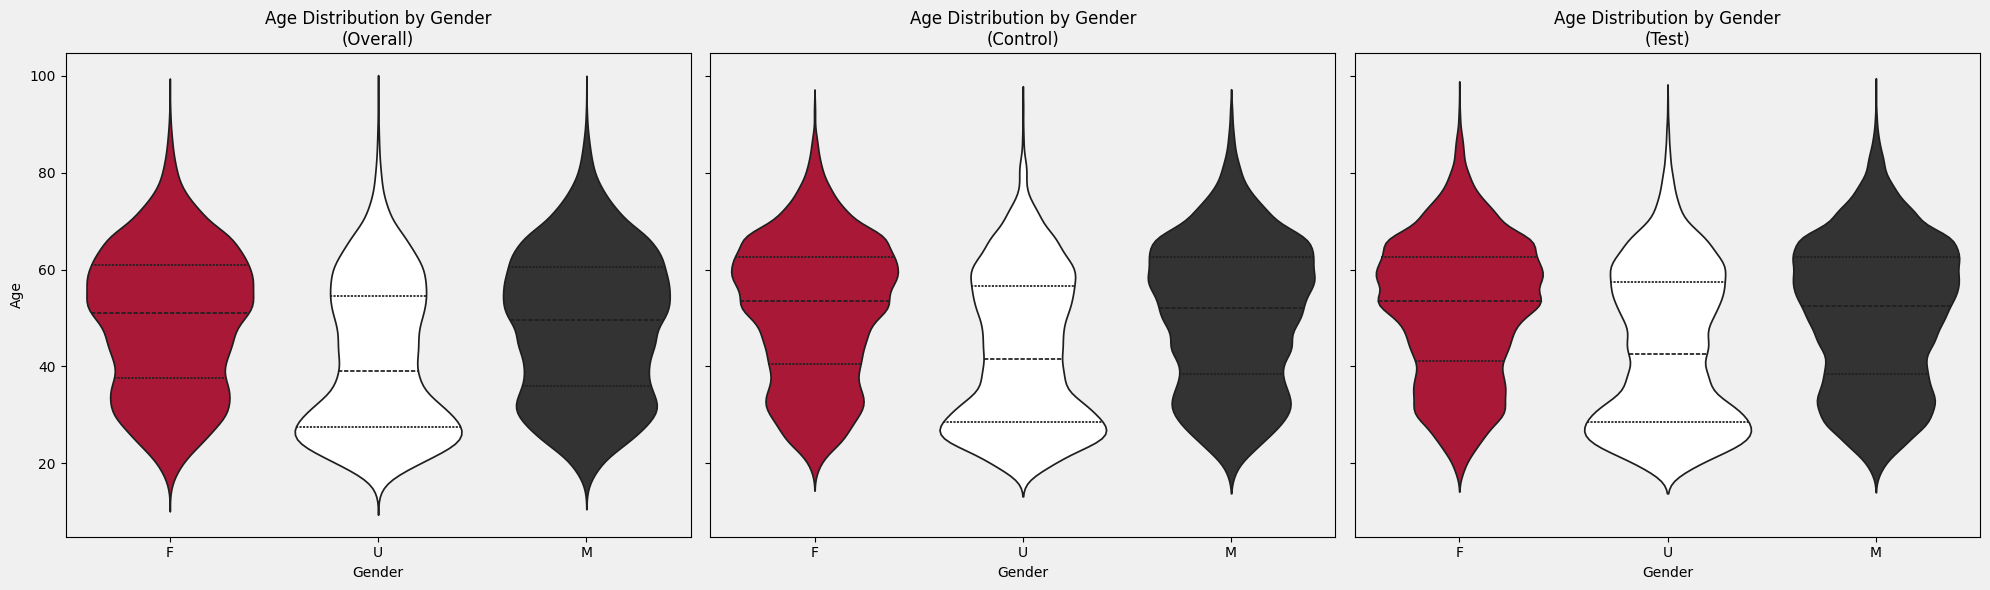

In [23]:
# full AI support (out of prompting and defining which plot and which data)

# Re-check data cleaning, nan = Unknown
df_clean = df.copy()
df_clean['gendr'] = df_clean['gendr'].str.upper().map({'F':'F','M':'M'}).fillna('U')
df_clean = df_clean[['gendr','clnt_age','Variation']]

# clean final demo gender
overall_clean = final_demo.copy()
overall_clean['gendr'] = overall_clean['gendr'].str.upper().map({'F':'F','M':'M'}).fillna('U')
overall_clean = overall_clean[['gendr','clnt_age']]
overall_clean['Variation'] = 'Overall'  # on ajoute la colonne Variation pour pouvoir concaténer

# concate
combined_df = pd.concat([overall_clean, df_clean], axis=0)

# violin subplots with vanguard graphic chart
gender_palette = {'F':'#C20029','M':'#333333','U':'#FFFFFF'}
gender_order = ['F','U','M']

fig, axes = plt.subplots(1, 3, figsize=(20,6), sharey=True)
fig.patch.set_facecolor('#f0f0f0')

for i, group in enumerate(['Overall','Control','Test']):
    sns.violinplot(
        x='gendr',
        y='clnt_age',
        data=combined_df[combined_df['Variation']==group],
        palette=gender_palette,
        order=gender_order,
        inner='quartile',
        ax=axes[i]
    )
    axes[i].set_title(f"Age Distribution by Gender\n({group})")
    axes[i].set_xlabel("Gender")
    axes[i].set_ylabel("Age" if i==0 else "")
    axes[i].set_facecolor('#f0f0f0')

plt.tight_layout()

# export
plt.savefig("violin_age_gender_groups.png", dpi=300, bbox_inches='tight')
plt.show()

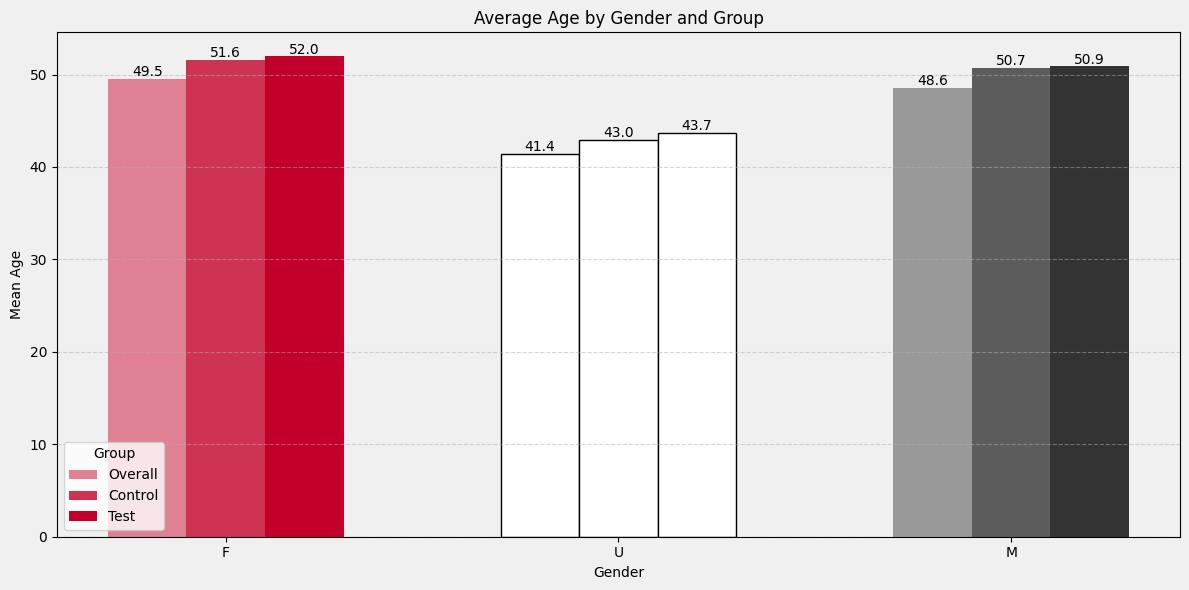

In [25]:
# Similar support comparing age mean of each gender per group

# clean df
df_clean = df.copy()
df_clean['gendr'] = df_clean['gendr'].str.upper().map({'F':'F','M':'M'}).fillna('U')
df_clean = df_clean[['gendr','clnt_age','Variation']]

# clean demo
overall_clean = final_demo.copy()
overall_clean['gendr'] = overall_clean['gendr'].str.upper().map({'F':'F','M':'M'}).fillna('U')
overall_clean = overall_clean[['gendr','clnt_age']]
overall_clean['Variation'] = 'Overall'

# mean calculation
mean_age_test_control = df_clean.groupby(['Variation','gendr'])['clnt_age'].mean().reset_index().rename(columns={'clnt_age':'mean_age'})
mean_age_overall = overall_clean.groupby(['gendr'])['clnt_age'].mean().reset_index()
mean_age_overall['Variation'] = 'Overall'
mean_age_overall = mean_age_overall.rename(columns={'clnt_age':'mean_age'})

# concate
mean_age_all = pd.concat([mean_age_overall, mean_age_test_control], axis=0)

# vanguard colors
base_colors = {'F':'#C20029','M':'#333333','U':'#FFFFFF'}

# functions for ligtening colors
def lighten_color(color, amount=0.5):
    r, g, b = to_rgb(color)
    r = r + (1-r)*amount
    g = g + (1-g)*amount
    b = b + (1-b)*amount
    return to_hex((r,g,b))

group_shades = {
    'F': {'Overall': lighten_color(base_colors['F'],0.5), 'Control': lighten_color(base_colors['F'],0.2), 'Test': base_colors['F']},
    'M': {'Overall': lighten_color(base_colors['M'],0.5), 'Control': lighten_color(base_colors['M'],0.2), 'Test': base_colors['M']},
    'U': {'Overall': lighten_color(base_colors['U'],0.5), 'Control': lighten_color(base_colors['U'],0.2), 'Test': base_colors['U']}
}

gender_order = ['F','U','M']
group_order = ['Overall','Control','Test']

# plot
plt.figure(figsize=(12,6), facecolor='#f0f0f0')
ax = plt.gca()

bar_width = 0.2
for i, g in enumerate(gender_order):
    for j, grp in enumerate(group_order):
        val = mean_age_all[(mean_age_all['gendr']==g) & (mean_age_all['Variation']==grp)]['mean_age'].values[0]
        x = i + (j-1)*bar_width
        color = group_shades[g][grp]
        edge = 'black' if g=='U' else 'none'
        ax.bar(x, val, width=bar_width, color=color, edgecolor=edge)
        ax.text(x, val+0.3, f"{val:.1f}", ha='center', fontsize=10)

# axes
ax.set_xticks(range(len(gender_order)))
ax.set_xticklabels(gender_order)
ax.set_ylabel("Mean Age")
ax.set_xlabel("Gender")
ax.set_facecolor('#f0f0f0')
plt.title("Average Age by Gender and Group")

# legend
legend_handles = [Patch(facecolor=group_shades['F'][grp], label=grp) for grp in group_order]
plt.legend(handles=legend_handles, title='Group', loc='lower left')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# export
plt.savefig("average_age_by_gender_group_with_overall.png", dpi=300, bbox_inches='tight', facecolor='#f0f0f0')

plt.show()

No significant difference observed among groups.

In [27]:
final_demo.gendr.value_counts()

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64